Dataset loaded successfully!

First 5 rows:
       0     1         2          3             4             5   \
0  record  type  0_pre-RR  0_post-RR       0_pPeak       0_tPeak   
1     I01     N       163        165   0.069610222  -0.083280601   
2     I01     N       165        166  -0.097030038   0.597254429   
3     I01     N       166        102   0.109399148    0.68052794   
4     I01   VEB       102        231   0.176376471   0.256431069   

             6             7             8               9   ...  \
0       0_rPeak       0_sPeak       0_qPeak  0_qrs_interval  ...   
1   0.614133158  -0.392761319   0.047159284              15  ...   
2  -0.078703617  -0.078703617  -0.137781281               3  ...   
3  -0.010648647  -0.010648647  -0.720620469               6  ...   
4  -0.101097641  -0.707524945  -0.101097641               4  ...   

             24              25             26             27             28  \
0       1_qPeak  1_qrs_interval  1_pq_interval  1_qt_inter

,record,type,0_pre-RR,0_post-RR,0_pPeak,0_tPeak,0_rPeak,0_sPeak,0_qPeak,0_qrs_interval,...,1_qPeak,1_qrs_interval,1_pq_interval,1_qt_interval,1_st_interval,1_qrs_morph0,1_qrs_morph1,1_qrs_morph2,1_qrs_morph3,1_qrs_morph4
0,I01,0,163,165,0.069610,-0.083281,0.614133,-0.392761,0.047159,15,...,-0.023370,14,3,23,6,-0.023370,-0.011650,0.082608,0.101373,-0.183387
1,I01,0,165,166,-0.097030,0.597254,-0.078704,-0.078704,-0.137781,3,...,0.081637,15,5,27,7,0.081637,0.102992,0.191225,0.217544,-0.068248
2,I01,0,166,102,0.109399,0.680528,-0.010649,-0.010649,-0.720620,6,...,-0.148539,33,13,52,6,-0.148539,-0.060620,0.081080,0.204400,0.335172
3,I01,1,102,231,0.176376,0.256431,-0.101098,-0.707525,-0.101098,4,...,0.046898,21,9,34,4,0.046898,0.083728,0.279512,0.526785,0.450969
4,I01,0,231,165,0.585577,0.607461,-0.083499,-0.083499,-0.167858,3,...,-0.112552,32,5,43,6,-0.112552,0.012989,0.091491,0.134004,0.265232



 Random Forest Analysis
Accuracy: 0.9955
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1838
           1       0.99      0.96      0.97       162

    accuracy                           1.00      2000
   macro avg       0.99      0.98      0.98      2000
weighted avg       1.00      1.00      1.00      2000


Top 10 Random Forest Features:
          feature  importance
16       1_pre-RR    0.165862
0        0_pre-RR    0.156550
21        1_sPeak    0.109975
20        1_rPeak    0.089909
26  1_st_interval    0.081011
30   1_qrs_morph3    0.056196
5         0_sPeak    0.037923
15   0_qrs_morph4    0.035497
17      1_post-RR    0.026921
31   1_qrs_morph4    0.026002


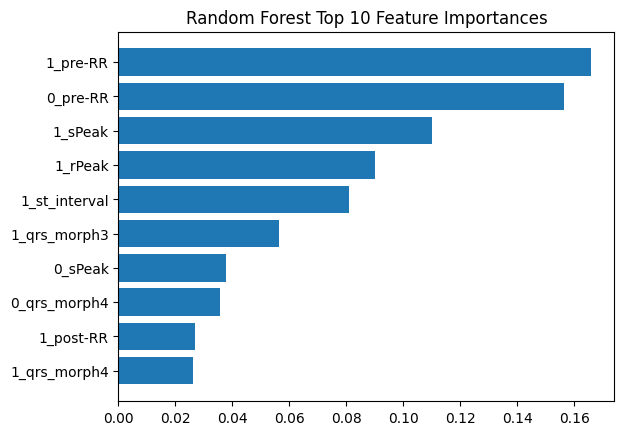

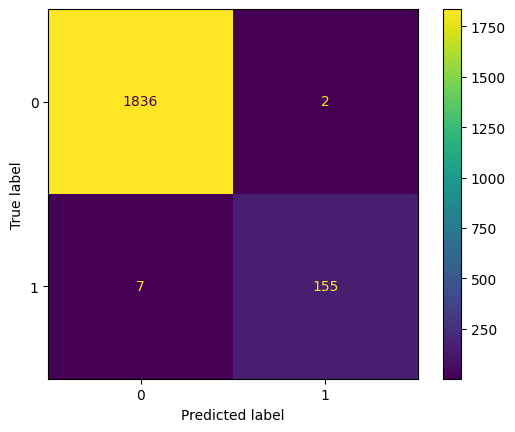

In [3]:
#-----PART 1: Download dataset-----
# ChatGPT was used for this part.

import pandas as pd
import os
import requests
from zipfile import ZipFile
from io import BytesIO

url = "https://www.kaggle.com/api/v1/datasets/download/sadmansakib7/ecg-arrhythmia-classification-dataset"

os.makedirs("data", exist_ok=True)
zip_path = "data/dataset.zip"

try:
    if not os.path.exists(zip_path):
        print("Downloading dataset...")
        response = requests.get(url)

        with open(zip_path, "wb") as f:
            f.write(response.content)

        with ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall("data")

    # Load CSV after extraction
    file_path = "data/INCART 2-lead Arrhythmia Database.csv"

    df = pd.read_csv(file_path, nrows=10000, header=None)
    print("Dataset loaded successfully!")

except Exception as e:
    print("Error loading dataset:", e)


#-----PART 2: Clean dataset to make it more useful for machine learning analysis-----
# Rename columns to the names in the first row of dataset.
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True) #Removes first row and reindexes

# The next is to adjust the classes to 0 for normal and 1 for abnormal
# This simplifies analysis.
col = df.columns[1]
df[col] = df[col].astype(str)
df[col] = (df[col] != 'N').astype(int)

#-----PART 3: Prepare newly cleaned dataset for machine learning-----

# Separate features and classes
# Features are from columns 2 to 34
X_cols = df.columns[2:34]
df[X_cols] = df[X_cols].apply(pd.to_numeric, errors='coerce')
df[X_cols] = df[X_cols].fillna(df[X_cols].mean()) # Fill missing data with the mean

# Features
X = df[X_cols]
y = df[col]

# Display the modified data set to confirm our dataset looks like what we think.
display(df.head())

# Import train_test_split function
from sklearn.model_selection import train_test_split

# Split the dataset using 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#-----PART 5: Machine learning-----

# Import tree library from sklearn
from sklearn import tree

# Import corresponding libraries for model evaluation
from sklearn.metrics import accuracy_score, classification_report

# Import Random Forest libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# ChatGPT and Homework 7 for class were used to write this subsection's code.
random_forest = RandomForestClassifier(
    n_estimators=200,
    criterion='entropy',
    min_samples_split=15,
    random_state=42
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

#-----PART 6: Analysis of Random Forest-----
print("\n Random Forest Analysis")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Display the features in order of importance.
rf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': random_forest.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop 10 Random Forest Features:")
print(rf_importance.head(10))

top_rf = rf_importance.head(10)

plt.figure()
plt.barh(top_rf['feature'], top_rf['importance'])
plt.gca().invert_yaxis()
plt.title("Random Forest Top 10 Feature Importances")
plt.show()

# Display confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
